In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

In [4]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [5]:
df["target"] = iris.target

In [6]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [11]:
# Evaluating the model 

In [12]:
accuracy = accuracy_score(y_test, y_pred)

In [13]:
conf_matrix = confusion_matrix(y_test, y_pred)

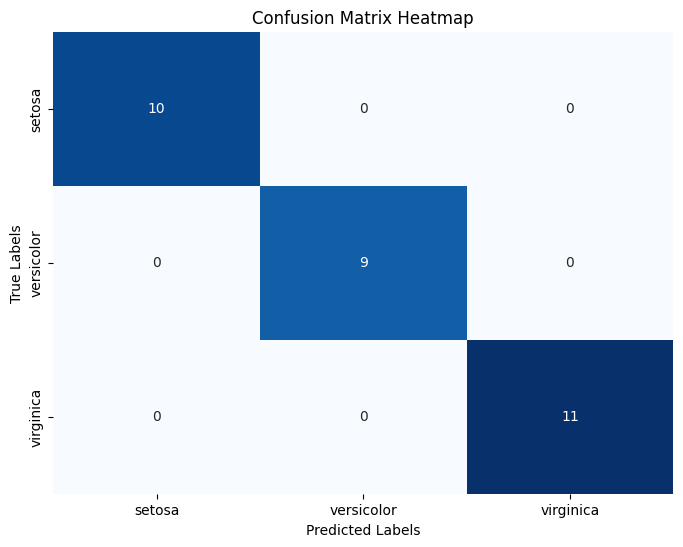

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="g",
    cmap="Blues",
    cbar=False,
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [16]:
feature_importance = classifier.feature_importances_

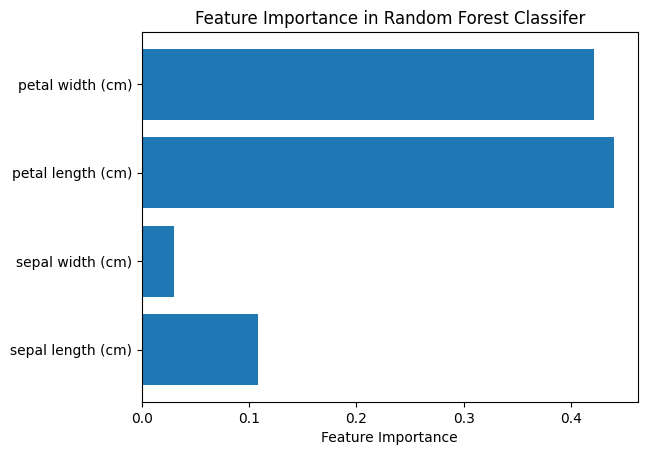

In [17]:
plt.barh(iris.feature_names, feature_importance)
plt.xlabel("Feature Importance")
plt.title("Feature Importance in Random Forest Classifer")
plt.show()